# TrOCR: fine-tune and evaluate (RxHandBD-ML)

Fine-tune `microsoft/trocr-base-handwritten` on **Train_Set** and compare the **pretrained** base model to the **fine-tuned** checkpoint on **Test_Set** (WER, CER, line accuracy).

**Environment:** use **[uv](https://docs.astral.sh/uv/)** (not `pip`): `uv sync`, then e.g. `uv run jupyter lab`.

**Data:** `real_dataset/RxHandBD-ML/` with `Train_Label.csv`, `Test_Label.csv`, `Train_Set/`, `Test_Set/`. **First run** downloads TrOCR (network required).

**Tuning:** change the next cell (batch size, epochs, paths, seed).

In [1]:
# --- config ---
from pathlib import Path
import os

DATA_ROOT = Path("real_dataset/RxHandBD-ML")
PRETRAINED = "microsoft/trocr-base-handwritten"
OUTPUT_DIR = Path("outputs/trocr-rxhand")

SEED = 42
VAL_FRACTION = 0.08
MAX_LABEL_TOKENS = 64
EPOCHS = 3
TRAIN_BATCH = 4
EVAL_BATCH = 4
LEARNING_RATE = 5e-5
WARMUP_RATIO = 0.05
LOGGING_STEPS = 25
MAX_GRAD_NORM = 0.1
GEN_MAX_LEN = 64
GEN_NUM_BEAMS = 1

# DataLoader workers: parallel image decode + batching (faster on CPU I/O). Use 0 if workers crash.
DATALOADER_NUM_WORKERS = 2

os.environ["PYTHONHASHSEED"] = str(SEED)

In [2]:
import json
import random
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from jiwer import cer, process_words, wer
from PIL import Image
from torch.utils.data import Dataset
from transformers import (
    EvalPrediction,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    TrOCRProcessor,
    VisionEncoderDecoderModel,
)

In [3]:
def set_seed(s: int) -> None:
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)


set_seed(SEED)

TRAIN_CSV = DATA_ROOT / "Train_Label.csv"
TEST_CSV = DATA_ROOT / "Test_Label.csv"
train_raw = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
for d in (train_raw, test_df):
    d.columns = [c.strip() for c in d.columns]
assert "Images" in train_raw.columns and "Text" in train_raw.columns

train_df = train_raw.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
n = len(train_df)
n_val = max(1, int(round(n * VAL_FRACTION)))
n_train = n - n_val
train_only = train_df.iloc[:n_train]
val_df = train_df.iloc[n_train:]

assert (DATA_ROOT / "Train_Set" / str(train_df.iloc[0]["Images"])).is_file()
assert (DATA_ROOT / "Test_Set" / str(test_df.iloc[0]["Images"])).is_file()

print(
    f"rows: total train={n} | fit={n_train} | val={n_val} | test={len(test_df)}"
)
print("train[0]:", train_df.iloc[0].to_dict())
print("test[0] :", test_df.iloc[0].to_dict())

# Batching + device: Trainer steps use TRAIN_BATCH images at a time; eval uses EVAL_BATCH.
_cuda = torch.cuda.is_available()
print(
    "Runtime:",
    f"device={'cuda:0 ' + torch.cuda.get_device_name(0) if _cuda else 'cpu (no usable GPU)'}",
    f"| train/eval batch sizes = {TRAIN_BATCH}/{EVAL_BATCH}",
    f"| fp16 in training = {_cuda}",
)
if not _cuda:
    print(
        "  → TrOCR on CPU is very slow. If you have an NVIDIA GPU, fix the driver / install a "
        "PyTorch build that matches your CUDA (see pytorch.org). Current run uses CPU + fp32."
    )

rows: total train=4463 | fit=4106 | val=357 | test=1115
train[0]: {'Images': 'P1413.jpg', 'Text': 'Nabu'}
test[0] : {'Images': 'P0001.jpg', 'Text': 'Nexcital'}
Runtime: device=cuda:0 NVIDIA GeForce RTX 3080 | train/eval batch sizes = 4/4 | fp16 in training = True


In [4]:
class TrOCRLineDataset(Dataset):
    """One line image + ground-truth text, encoded for TrOCR."""

    def __init__(
        self, df: pd.DataFrame, image_subdir: str, processor, max_length: int
    ) -> None:
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(DATA_ROOT) / image_subdir
        self.processor = processor
        self.max_length = int(max_length)

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> dict:
        row = self.df.iloc[idx]
        name = str(row["Images"])
        text = str(row["Text"])
        path = self.image_dir / name
        image = Image.open(path).convert("RGB")
        enc = self.processor(
            image,
            text,
            return_tensors="pt",
            padding="max_length",
            max_length=self.max_length,
            truncation=True,
        )
        pixel_values = enc["pixel_values"].squeeze(0)
        labels = enc["labels"].squeeze(0)
        pad = self.processor.tokenizer.pad_token_id
        if pad is not None:
            m = labels == pad
            labels = labels.clone()
            labels[m] = -100
        return {
            "pixel_values": pixel_values,
            "labels": labels,
            "path": str(path),
        }


class TrOCRDataCollator:
    """Stack images; right-pad labels with -100. Strips `path` from the batch."""

    def __call__(self, features: List[dict]) -> dict:
        pixel_values = torch.stack([f["pixel_values"] for f in features], dim=0)
        max_len = max(f["labels"].size(0) for f in features)
        out: List[torch.Tensor] = []
        for f in features:
            l = f["labels"]
            p = max_len - l.size(0)
            if p:
                pad = torch.full((p,), -100, dtype=l.dtype, device=l.device)
                l = torch.cat([l, pad], dim=0)
            out.append(l)
        return {"pixel_values": pixel_values, "labels": torch.stack(out, dim=0)}

In [5]:
def align_model_to_processor(model, processor) -> None:
    tok = processor.tokenizer
    if getattr(model.config, "pad_token_id", None) is None and tok.pad_token_id is not None:
        model.config.pad_token_id = int(tok.pad_token_id)
    if (
        getattr(model.config, "decoder_start_token_id", None) is None
        and getattr(model.config, "pad_token_id", None) is not None
    ):
        model.config.decoder_start_token_id = int(model.config.pad_token_id)


def corpus_metrics(refs: List[str], hyps: List[str]) -> Dict[str, float]:
    def _safe(s: str) -> str:
        t = s or ""
        return t if t.strip() else " "

    r2 = [_safe(x) for x in refs]
    h2 = [_safe(x) for x in hyps]
    return {
        "wer": float(wer(r2, h2)),
        "cer": float(cer(r2, h2)),
        "seq_acc": float(np.mean([a == b for a, b in zip(r2, h2)])),
    }


def per_line_word_error_counts(refs: List[str], hyps: List[str]) -> List[int]:
    out: List[int] = []
    for r, h in zip(refs, hyps):
        a, b = (r or "").strip(), (h or "").strip()
        if a == b:
            out.append(0)
        else:
            p = process_words(" " if not a else a, " " if not b else b)
            out.append(int(p.substitutions + p.deletions + p.insertions))
    return out

In [6]:
processor = TrOCRProcessor.from_pretrained(PRETRAINED, use_fast=True)
model = VisionEncoderDecoderModel.from_pretrained(PRETRAINED)
align_model_to_processor(model, processor)

_tok = processor.tokenizer
_ml = int(getattr(_tok, "model_max_length", 1024) or 1024)
if _ml > 100_000:
    _ml = 1024
max_label_tokens = min(MAX_LABEL_TOKENS, _ml)

train_ds = TrOCRLineDataset(
    train_only, "Train_Set", processor, max_length=max_label_tokens
)
val_ds = TrOCRLineDataset(
    val_df, "Train_Set", processor, max_length=max_label_tokens
)
data_collator = TrOCRDataCollator()

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.
[transformers] `ViTImageProcessor` requires torchvision (not installed); falling back to `ViTImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `ViTImageProcessorPil` directly to silence this warning.


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
pad_id = int(processor.tokenizer.pad_token_id)
eos_id = int(
    processor.tokenizer.eos_token_id
    if processor.tokenizer.eos_token_id is not None
    else pad_id
)


def build_compute_metrics() -> Any:
    # Use full tokenizer size (includes added special tokens).
    vocab_size = int(len(processor.tokenizer))

    def _to_valid_token_ids(x: Any) -> np.ndarray:
        arr = np.asarray(x)
        if arr.ndim == 3:
            # logits -> token ids
            arr = arr.argmax(axis=-1)
        arr = np.nan_to_num(arr, nan=pad_id, posinf=pad_id, neginf=pad_id)
        arr = arr.astype(np.int64, copy=False)
        arr[(arr < 0) | (arr >= vocab_size)] = pad_id
        return arr

    def _safe_decode_batch(arr: np.ndarray) -> List[str]:
        # Build plain Python ints to avoid any backend conversion edge cases.
        seqs: List[List[int]] = []
        for row in np.asarray(arr):
            seq: List[int] = []
            for t in np.asarray(row).reshape(-1):
                try:
                    v = int(t)
                except Exception:
                    v = pad_id
                if v < 0 or v >= vocab_size:
                    v = pad_id
                seq.append(v)
            seqs.append(seq)
        return processor.batch_decode(
            seqs, skip_special_tokens=True, clean_up_tokenization_spaces=True
        )

    def fn(p: EvalPrediction) -> dict:
        pred_ids = p.predictions
        if isinstance(pred_ids, (list, tuple)):
            pred_ids = pred_ids[0]
        pred_ids = _to_valid_token_ids(pred_ids)

        li = np.array(p.label_ids, copy=True)
        li[li < 0] = pad_id
        li = _to_valid_token_ids(li)

        try:
            pred_str = _safe_decode_batch(pred_ids)
            ref_str = _safe_decode_batch(li)
        except OverflowError:
            # Last-resort fallback: decode token-by-token safely.
            pred_str = []
            ref_str = []
            for prow, rrow in zip(pred_ids, li):
                pseq = [pad_id if int(t) < 0 or int(t) >= vocab_size else int(t) for t in np.asarray(prow).reshape(-1)]
                rseq = [pad_id if int(t) < 0 or int(t) >= vocab_size else int(t) for t in np.asarray(rrow).reshape(-1)]
                pred_str.append(processor.decode(pseq, skip_special_tokens=True, clean_up_tokenization_spaces=True))
                ref_str.append(processor.decode(rseq, skip_special_tokens=True, clean_up_tokenization_spaces=True))

        return corpus_metrics(ref_str, pred_str)

    return fn

In [11]:
out_dir = str(OUTPUT_DIR)
use_cuda = torch.cuda.is_available()
training_args = Seq2SeqTrainingArguments(
    output_dir=out_dir,
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=LOGGING_STEPS,
    save_total_limit=2,
    per_device_train_batch_size=TRAIN_BATCH,
    per_device_eval_batch_size=EVAL_BATCH,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    num_train_epochs=float(EPOCHS),
    max_grad_norm=MAX_GRAD_NORM,
    fp16=use_cuda,
    dataloader_num_workers=DATALOADER_NUM_WORKERS,
    dataloader_pin_memory=use_cuda,
    report_to="none",
    remove_unused_columns=False,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    predict_with_generate=True,
    generation_max_length=GEN_MAX_LEN,
    generation_num_beams=GEN_NUM_BEAMS,
    seed=SEED,
    data_seed=SEED,
    logging_strategy="steps",
    optim="adamw_torch",
    lr_scheduler_type="cosine",
)

cm_fn = build_compute_metrics()
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=processor,
    data_collator=data_collator,
    compute_metrics=cm_fn,
)
train_out = trainer.train()
trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Saved to", OUTPUT_DIR, train_out)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Wer,Cer,Seq Acc
1,0.734468,1.217357,0.579208,0.626172,0.417367
2,0.363467,0.988407,0.480198,0.298818,0.563025
3,0.091508,1.021310,0.383663,0.138198,0.602241


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['decoder.output_projection.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to outputs/trocr-rxhand TrainOutput(global_step=3081, training_loss=0.35852414797126997, metrics={'train_runtime': 1093.1411, 'train_samples_per_second': 11.268, 'train_steps_per_second': 2.818, 'total_flos': 9.217376982688334e+18, 'train_loss': 0.35852414797126997, 'epoch': 3.0})


Using trainer state from latest checkpoint: outputs/trocr-rxhand/checkpoint-3081/trainer_state.json


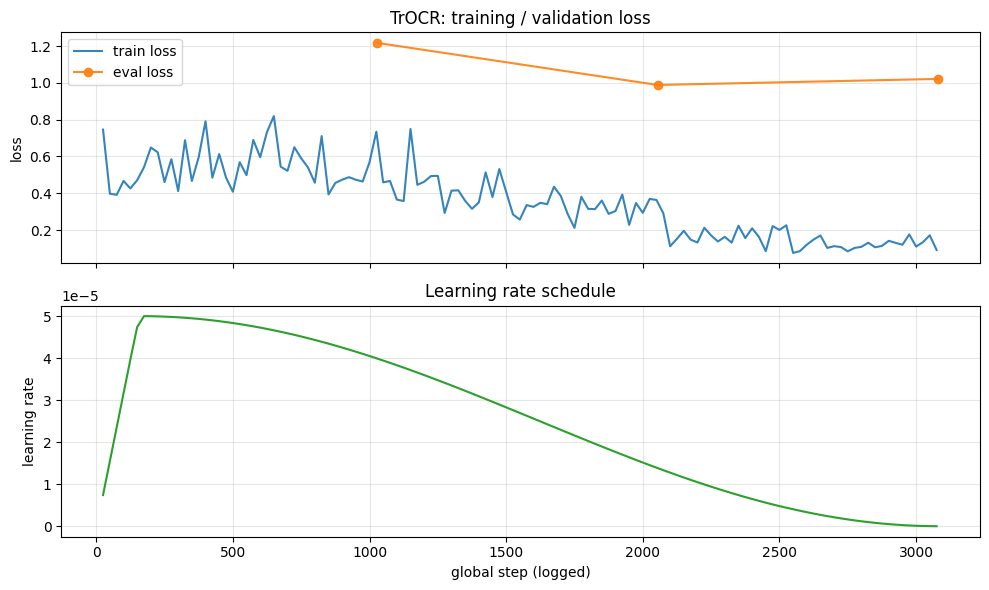

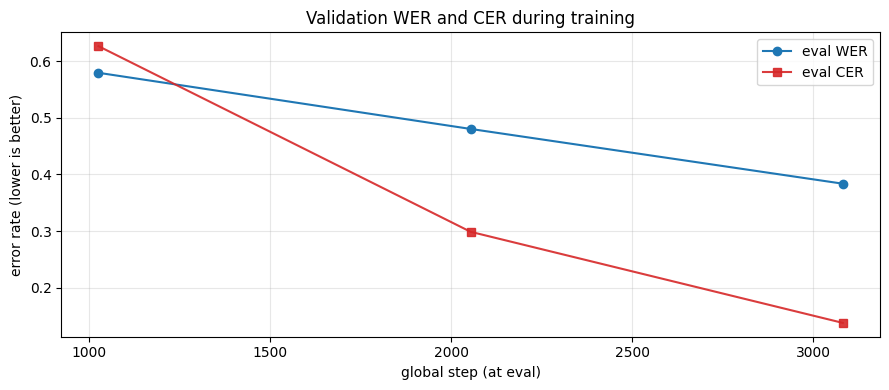

In [17]:
# Plots: loss, LR, validation WER/CER (from `trainer_state.json` -> `log_history`)
state_path = OUTPUT_DIR / "trainer_state.json"
if not state_path.is_file():
    # HF Trainer writes trainer_state.json inside checkpoint-* when save_strategy is enabled.
    checkpoint_states = sorted(
        OUTPUT_DIR.glob("checkpoint-*/trainer_state.json"),
        key=lambda p: p.stat().st_mtime,
    )
    if checkpoint_states:
        state_path = checkpoint_states[-1]
        print(f"Using trainer state from latest checkpoint: {state_path}")
    else:
        raise FileNotFoundError(
            f"Missing {state_path.resolve()!s} and no checkpoint-*/trainer_state.json found. "
            "Run the training cell above first, or fix OUTPUT_DIR / notebook working directory."
        )
with open(state_path) as f:
    tstate = json.load(f)
logs: List[dict] = tstate.get("log_history", [])


def log_series(*keys: str) -> List[Tuple[int, float]]:
    """First matching key with any points wins (HF usually logs `eval_wer`, not `wer`)."""
    for key in keys:
        pts: List[Tuple[int, float]] = []
        for i, row in enumerate(logs):
            if key in row:
                st = int(row.get("step", i))
                pts.append((st, float(row[key])))
        if pts:
            return pts
    return []


tloss = log_series("loss")
eloss = log_series("eval_loss")
elr = log_series("learning_rate")
ewer = log_series("eval_wer", "wer")
ecer = log_series("eval_cer", "cer")

# Helpful if custom metrics are renamed in a future `transformers` version
if logs and not ewer and not ecer:
    sample_eval = sorted(
        {k for r in logs for k in r if str(k).startswith("eval_")}
        - {"eval_loss", "eval_runtime", "eval_samples_per_second", "eval_steps_per_second"}
    )
    if sample_eval:
        print("Tip: `log_history` has no eval_wer/eval_cer; eval_* keys present:", sample_eval)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
if tloss:
    sx, sy = zip(*tloss)
    axes[0].plot(sx, sy, label="train loss", color="C0", alpha=0.9)
if eloss:
    sx, sy = zip(*eloss)
    axes[0].plot(sx, sy, label="eval loss", color="C1", marker="o", alpha=0.9)
axes[0].set_ylabel("loss")
axes[0].set_title("TrOCR: training / validation loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
if elr:
    sx, sy = zip(*elr)
    axes[1].plot(sx, sy, color="C2")
axes[1].set_xlabel("global step (logged)")
axes[1].set_ylabel("learning rate")
axes[1].set_title("Learning rate schedule")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(1, 1, figsize=(9, 4))
if ewer:
    sx, sy = zip(*ewer)
    ax2.plot(sx, sy, label="eval WER", marker="o", color="C0")
if ecer:
    sx, sy = zip(*ecer)
    ax2.plot(sx, sy, label="eval CER", marker="s", color="C3", alpha=0.9)
ax2.set_xlabel("global step (at eval)")
ax2.set_ylabel("error rate (lower is better)")
ax2.set_title("Validation WER and CER during training")
if ewer or ecer:
    ax2.legend()
ax2.grid(True, alpha=0.3)
if not ewer and not ecer and logs:
    ax2.set_title("No WER/CER in log_history (re-run training with compute_metrics)")
plt.tight_layout()
plt.show()

In [18]:
def evaluate_model_on_df(
    mdl: VisionEncoderDecoderModel,
    proc: TrOCRProcessor,
    df: pd.DataFrame,
    subdir: str = "Test_Set",
    batch_size: int = 4,
    device: Optional[torch.device] = None,
) -> dict:
    """Run `generate` on all rows; return metrics and per-line paths/refs/preds."""
    if device is None:
        device = next(mdl.parameters()).device
    mdl.eval()
    mdl.to(device)
    names = df["Images"].astype(str).tolist()
    refs = df["Text"].astype(str).tolist()
    paths: List[Path] = [DATA_ROOT / subdir / n for n in names]
    preds: List[str] = []
    for s0 in range(0, len(paths), batch_size):
        part = paths[s0 : s0 + batch_size]
        imgs = [Image.open(p).convert("RGB") for p in part]
        enc = proc(images=imgs, return_tensors="pt", padding=True)
        px = enc["pixel_values"].to(device)
        gen = mdl.generate(
            px,
            max_length=GEN_MAX_LEN,
            num_beams=GEN_NUM_BEAMS,
            pad_token_id=pad_id,
            eos_token_id=eos_id,
        )
        out = proc.batch_decode(
            gen, skip_special_tokens=True, clean_up_tokenization_spaces=True
        )
        preds.extend(out)
    m = corpus_metrics(refs, preds)
    return {
        **m,
        "n_samples": len(refs),
        "paths": [str(p) for p in paths],
        "refs": list(refs),
        "preds": list(preds),
    }

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mdl_base = VisionEncoderDecoderModel.from_pretrained(PRETRAINED)
mdl_base.to(device)
align_model_to_processor(mdl_base, processor)
res_base = evaluate_model_on_df(
    mdl_base, processor, test_df, "Test_Set", batch_size=EVAL_BATCH, device=device
)

mdl_ft = VisionEncoderDecoderModel.from_pretrained(OUTPUT_DIR)
mdl_ft.to(device)
align_model_to_processor(mdl_ft, processor)
proc_out = TrOCRProcessor.from_pretrained(OUTPUT_DIR)
res_ft = evaluate_model_on_df(
    mdl_ft, proc_out, test_df, "Test_Set", batch_size=EVAL_BATCH, device=device
)

summary = pd.DataFrame(
    {
        "Model": ["base (pretrained)", "fine-tuned"],
        "WER": [res_base["wer"], res_ft["wer"]],
        "CER": [res_base["cer"], res_ft["cer"]],
        "Line acc (exact)": [res_base["seq_acc"], res_ft["seq_acc"]],
        "n (test)": [res_base["n_samples"], res_ft["n_samples"]],
    }
)
print(summary.to_string(index=False))
print()
print(
    "Delta (base - fine)  WER:",
    round(res_base["wer"] - res_ft["wer"], 6),
    "  CER:",
    round(res_base["cer"] - res_ft["cer"], 6),
)

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

            Model      WER      CER  Line acc (exact)  n (test)
base (pretrained) 1.457559 0.705392          0.078924      1115
       fine-tuned 0.706548 0.332014          0.313004      1115

Delta (base - fine)  WER: 0.751011   CER: 0.373379


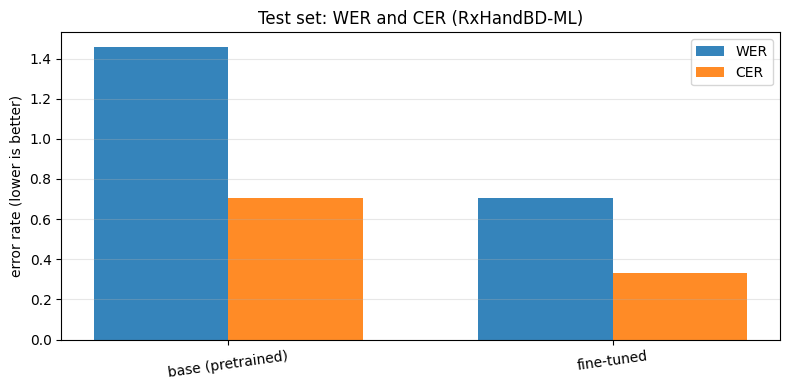

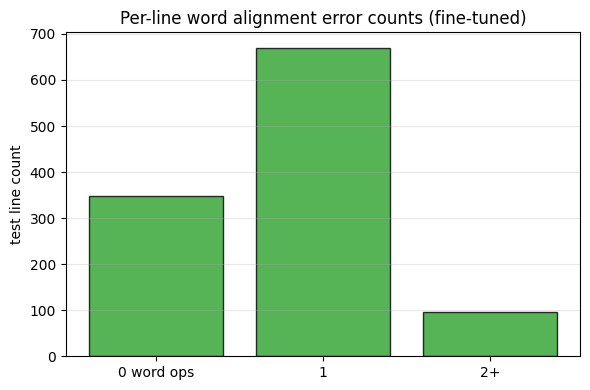

In [20]:
# Test set: grouped bar (WER / CER) + bucketed word error counts
x = np.arange(2)
w = 0.35
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.bar(
    x - w / 2, [res_base["wer"], res_ft["wer"]], w, label="WER", color="C0", alpha=0.9
)
ax.bar(
    x + w / 2, [res_base["cer"], res_ft["cer"]], w, label="CER", color="C1", alpha=0.9
)
ax.set_xticks(x, ["base (pretrained)", "fine-tuned"], rotation=8)
ax.set_ylabel("error rate (lower is better)")
ax.set_title("Test set: WER and CER (RxHandBD-ML)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

e_ft = per_line_word_error_counts(res_ft["refs"], res_ft["preds"])
b0 = sum(1 for e in e_ft if e == 0)
b1 = sum(1 for e in e_ft if e == 1)
b2p = sum(1 for e in e_ft if e >= 2)
fig2, ax2 = plt.subplots(1, 1, figsize=(6, 4))
ax2.bar(
    ["0 word ops", "1", "2+"],
    [b0, b1, b2p],
    color="C2",
    edgecolor="black",
    alpha=0.8,
)
ax2.set_ylabel("test line count")
ax2.set_title("Per-line word alignment error counts (fine-tuned)")
ax2.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

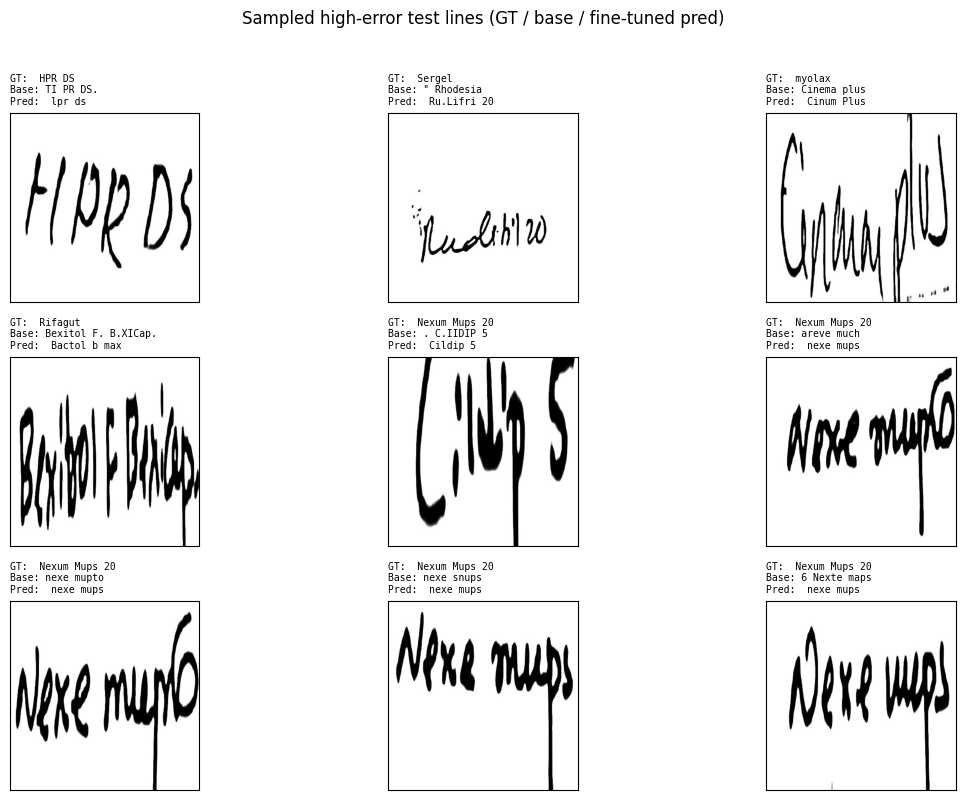

In [21]:
# Hard examples: sort mistakes by word ops, then sample with a fixed seed
HARD_N = 9
HARD_SEED = 7
rng = random.Random(HARD_SEED)


def word_ops(r: str, p: str) -> int:
    a, b = (r or "").strip(), (p or "").strip()
    pwo = process_words(" " if not a else a, " " if not b else b)
    return int(pwo.substitutions + pwo.deletions + pwo.insertions)


wrong = [i for i, (r, p) in enumerate(zip(res_ft["refs"], res_ft["preds"])) if r != p]
wrong.sort(key=lambda j: -word_ops(res_ft["refs"][j], res_ft["preds"][j]))
cand = wrong[: max(3 * HARD_N, HARD_N)]
pick = rng.sample(cand, k=min(HARD_N, len(cand))) if cand else []
pick.sort()

if not pick:
    print("No incorrect predictions on the test set to display.")
else:
    nc, nr = 3, int(np.ceil(len(pick) / 3))
    fig, axes = plt.subplots(nr, nc, figsize=(4.2 * nc, 2.6 * nr))
    axes = np.array(axes).ravel()
    for k, ax in enumerate(axes):
        if k >= len(pick):
            ax.axis("off")
            continue
        j = pick[k]
        im = Image.open(res_ft["paths"][j]).convert("RGB")
        ax.imshow(im)
        t = f"GT:  {res_ft['refs'][j]}\nBase: {res_base['preds'][j]}\nPred:  {res_ft['preds'][j]}"
        ax.set_title(t, fontsize=7, family="monospace", loc="left")
        ax.set_xticks([])
        ax.set_yticks([])
    plt.suptitle("Sampled high-error test lines (GT / base / fine-tuned pred)", y=1.02)
    plt.tight_layout()
    plt.show()